In [1]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from collections import defaultdict
import matplotlib.pyplot as plt

In [88]:
df = pd.read_excel("./datasets/Specimens-Train.xlsx")

cols = ["TOTAL SPECIMENS", "TOTAL A", "TOTAL B"]
df = df[cols].dropna().reset_index(drop=True)

print(f"Data loaded. Total length: {len(df)}")


Data loaded. Total length: 238


In [89]:
split_ratio = 0.8
split_idx = int(split_ratio * len(df))

train_df = df.iloc[:split_idx].copy().reset_index(drop=True)
test_df  = df.iloc[split_idx:].copy().reset_index(drop=True)

print(f"Train: {len(train_df)} samples ({split_ratio*100:.0f}%)")
print(f"Test : {len(test_df)} samples ({(1-split_ratio)*100:.0f}%)")

Train: 190 samples (80%)
Test : 48 samples (20%)


In [90]:
def create_lagged(df, lag=1):
    X, Y = [], []
    for i in range(lag, len(df)):
        X.append(df.iloc[i-lag].values)   # inputs at t-1
        Y.append(df.iloc[i].values)       # outputs at t
    return np.array(X), np.array(Y)

X_train, Y_train = create_lagged(train_df, lag=1)
X_test,  Y_test  = create_lagged(test_df,  lag=1)

print("\nLagged dataset created:")
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_test  shape:", X_test.shape)
print("Y_test  shape:", Y_test.shape)


Lagged dataset created:
X_train shape: (189, 3)
Y_train shape: (189, 3)
X_test  shape: (47, 3)
Y_test  shape: (47, 3)


In [91]:
expansion_factor = 0.2

universes = {}

for col in train_df.columns:
    y_min = train_df[col].min()
    y_max = train_df[col].max()
    
    D = expansion_factor * (y_max - y_min)
    U_min = y_min - D
    U_max = y_max + D
    
    universes[col] = (U_min, U_max)
    
    print(f"{col}")
    print(f"  U_min: {U_min:.4f}   U_max: {U_max:.4f}")

TOTAL SPECIMENS
  U_min: -11517.8000   U_max: 225668.8000
TOTAL A
  U_min: -9763.4000   U_max: 58601.4000
TOTAL B
  U_min: -1626.2000   U_max: 9820.2000


In [128]:
c_selected = 2# recommended for MVFTS (5–9 is common)
print(f"Selected number of fuzzy sets per variable: {c_selected}\n")

fuzzy_centers = {}

for col in train_df.columns:
    
    values = train_df[col].values.reshape(1, -1)
    
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        values,
        c=c_selected,
        m=2.0,
        error=0.005,
        maxiter=1000
    )
    
    centers_sorted = np.sort(cntr.flatten())
    fuzzy_centers[col] = centers_sorted
    
    print(f"{col} centers:")
    print(np.round(centers_sorted, 4))
    print()

Selected number of fuzzy sets per variable: 2

TOTAL SPECIMENS centers:
[ 49279.3693 120645.7991]

TOTAL A centers:
[ 1806.3575 29992.0048]

TOTAL B centers:
[ 171.4574 5621.205 ]



In [129]:
# -------------------------------------------------
# 6) BUILD TRIANGULAR FUZZY SETS FOR EACH VARIABLE
# -------------------------------------------------
fuzzy_sets = {}   # dictionary: variable → list of (a,b,c)

for col in train_df.columns:
    
    centers = fuzzy_centers[col]
    U_min, U_max = universes[col]
    
    # mid boundaries between centers
    boundaries = [(centers[i] + centers[i+1]) / 2 for i in range(len(centers)-1)]

    # intervals of universe
    intervals = [(U_min, boundaries[0])]
    for i in range(len(boundaries)-1):
        intervals.append((boundaries[i], boundaries[i+1]))
    intervals.append((boundaries[-1], U_max))

    # create triangular sets
    sets = []
    for i in range(len(centers)):
        if i == 0:
            a, b, c = intervals[0][0], centers[0], centers[1]
        elif i == len(centers)-1:
            a, b, c = centers[-2], centers[-1], intervals[-1][1]
        else:
            a, b, c = centers[i-1], centers[i], centers[i+1]
        sets.append((a,b,c))
    
    fuzzy_sets[col] = sets

# print result
for col in fuzzy_sets:
    print(f"\n{col} fuzzy sets:")
    for i,(a,b,c) in enumerate(fuzzy_sets[col],1):
        print(f"A{i}: {a:>8.4f} → {b:>8.4f} → {c:>8.4f}")



TOTAL SPECIMENS fuzzy sets:
A1: -11517.8000 → 49279.3693 → 120645.7991
A2: 49279.3693 → 120645.7991 → 225668.8000

TOTAL A fuzzy sets:
A1: -9763.4000 → 1806.3575 → 29992.0048
A2: 1806.3575 → 29992.0048 → 58601.4000

TOTAL B fuzzy sets:
A1: -1626.2000 → 171.4574 → 5621.2050
A2: 171.4574 → 5621.2050 → 9820.2000


In [130]:
# -------------------------------------------------
# 7) TRIANGULAR MEMBERSHIP FUNCTION
# -------------------------------------------------
def triangular_mf(x, a, b, c):
    if x <= a or x >= c:
        return 0.0
    if x <= b:
        return (x - a) / (b - a) if b != a else 0.0
    return (c - x) / (c - b) if c != b else 0.0

# -------------------------------------------------
# 8) FUZZIFY A SINGLE VALUE USING FUZZY SETS OF A VARIABLE
# -------------------------------------------------
def fuzzify_value(value, fuzzy_sets_var):
    memberships = [triangular_mf(value, *fs) for fs in fuzzy_sets_var]
    return np.argmax(memberships)

# -------------------------------------------------
# 9) VECTOR FUZZIFICATION (KEY UPGRADE ⭐)
#    Convert row → tuple of fuzzy labels
# -------------------------------------------------
def fuzzify_vector(row):
    labels = []
    for i, col in enumerate(train_df.columns):
        fs = fuzzy_sets[col]
        labels.append(fuzzify_value(row[i], fs))
    return tuple(labels)

# -------------------------------------------------
# 10) FUZZIFY TRAIN & TEST LAGGED DATA
# -------------------------------------------------
fuzzy_X_train = np.array([fuzzify_vector(x) for x in X_train])
fuzzy_Y_train = np.array([fuzzify_vector(y) for y in Y_train])

fuzzy_X_test  = np.array([fuzzify_vector(x) for x in X_test])
fuzzy_Y_test  = np.array([fuzzify_vector(y) for y in Y_test])

print("Fuzzy X_train sample:")
print(fuzzy_X_train[:5])

print("\nFuzzy Y_train sample:")
print(fuzzy_Y_train[:5])


Fuzzy X_train sample:
[[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]]

Fuzzy Y_train sample:
[[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]]


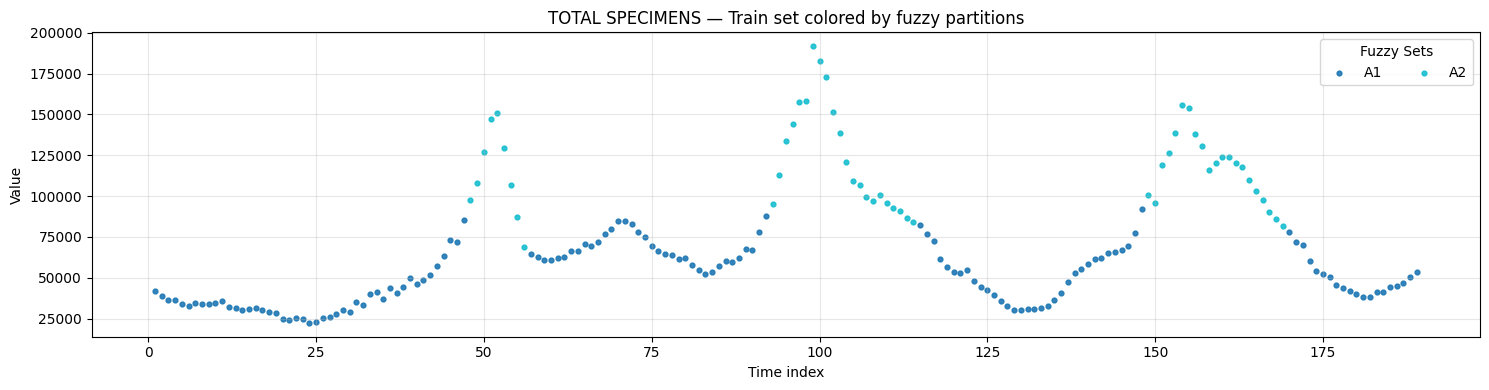

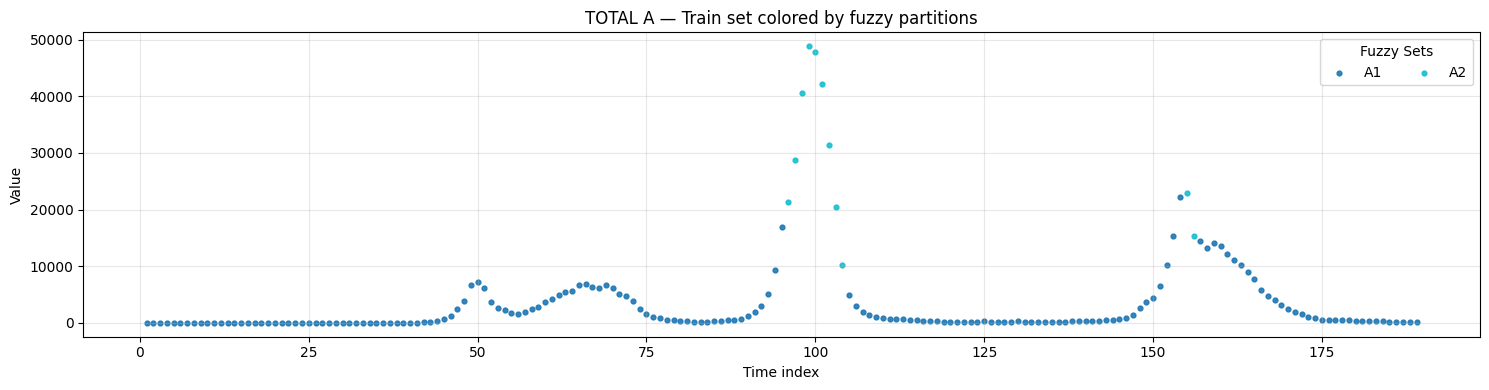

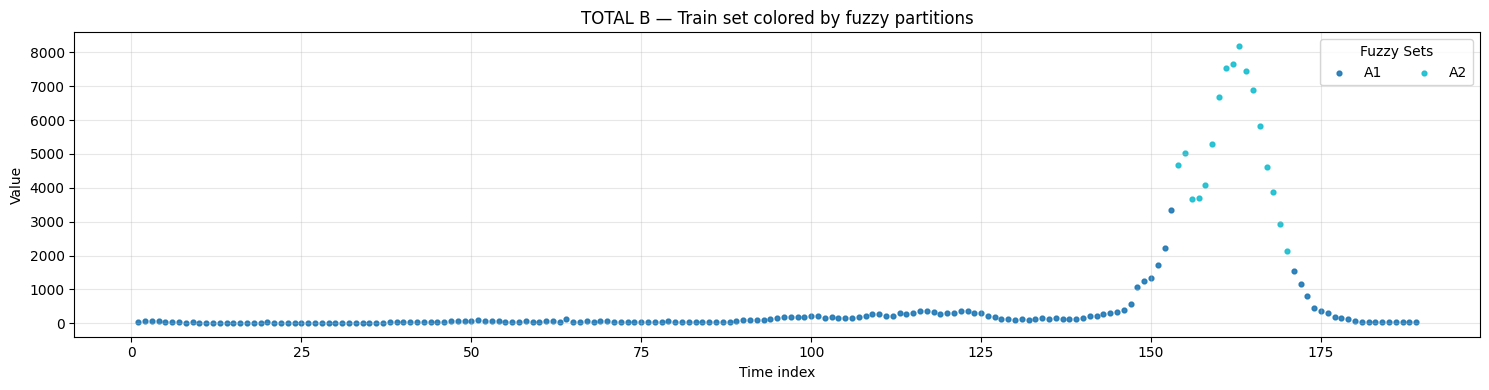

In [131]:
variables = train_df.columns
time_idx = np.arange(len(train_df))

for v, col in enumerate(variables):
    
    n_clusters = len(fuzzy_sets[col])
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
    
    values = train_df[col].values
    labels_var = fuzzy_X_train[:, v]   # fuzzy labels for this variable
    
    plt.figure(figsize=(15,4))
    
    for lbl in range(n_clusters):
        mask = (labels_var == lbl)
        plt.scatter(
            time_idx[1:][mask],  # shift because of lagged dataset
            values[1:][mask],
            color=colors[lbl],
            s=12,
            label=f"A{lbl+1}",
            alpha=0.9
        )
    
    plt.title(f"{col} — Train set colored by fuzzy partitions")
    plt.xlabel("Time index")
    plt.ylabel("Value")
    plt.legend(title="Fuzzy Sets", loc='upper right', ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [132]:
flrg_mimo = defaultdict(lambda: defaultdict(int))

for t in range(len(fuzzy_X_train) - 1):
    lhs = tuple(fuzzy_X_train[t])    # fuzzy labels at time t
    rhs = tuple(fuzzy_Y_train[t])    # fuzzy labels at time t+1
    flrg_mimo[lhs][rhs] += 1

# Print FLRG
print("MIMO FLRG (First-Order, Weighted):")
for lhs in sorted(flrg_mimo.keys()):
    rhs_parts = []
    for rhs, count in flrg_mimo[lhs].items():
        rhs_str = ",".join([f"A{lbl+1}" for lbl in rhs])
        rhs_parts.append(f"{rhs_str}({count})")
    lhs_str = ",".join([f"A{lbl+1}" for lbl in lhs])
    print(f"{lhs_str} → {', '.join(rhs_parts)}")

MIMO FLRG (First-Order, Weighted):
A1,A1,A1 → A1,A1,A1(132), A2,A1,A1(3)
A1,A1,A2 → A1,A1,A1(1)
A2,A1,A1 → A2,A1,A1(23), A1,A1,A1(2), A2,A2,A1(1), A2,A1,A2(1)
A2,A1,A2 → A2,A2,A2(1), A2,A1,A2(12), A1,A1,A2(1)
A2,A2,A1 → A2,A2,A1(8), A2,A1,A1(1)
A2,A2,A2 → A2,A2,A2(1), A2,A1,A2(1)


In [133]:
order = 2  # e.g., 2-step history

# Initialize nested dictionary
flrg_ho_mimo = defaultdict(lambda: defaultdict(int))

# Loop through fuzzified train data
for t in range(order, len(fuzzy_X_train)):
    # LHS: tuple of previous 'order' fuzzy vectors
    lhs = tuple(tuple(fuzzy_X_train[t - k - 1]) for k in reversed(range(order)))
    # RHS: fuzzy vector at current time
    rhs = tuple(fuzzy_Y_train[t])
    
    flrg_ho_mimo[lhs][rhs] += 1

# -------------------------------
# Print High-Order FLRG
# -------------------------------
print(f"MIMO High-Order FLRG (Weighted, order={order}):")
print("-" * 60)

for lhs_seq in sorted(flrg_ho_mimo.keys()):
    # Format LHS sequence
    lhs_parts = []
    for vec in lhs_seq:
        lhs_parts.append(",".join(f"A{lbl+1}" for lbl in vec))
    lhs_str = " → ".join(lhs_parts)
    
    # Format RHS options
    rhs_parts = []
    for rhs_vec, count in flrg_ho_mimo[lhs_seq].items():
        rhs_str = ",".join(f"A{lbl+1}" for lbl in rhs_vec)
        rhs_parts.append(f"{rhs_str}({count})")
    
    print(f"{lhs_str}  →  {', '.join(rhs_parts)}")

MIMO High-Order FLRG (Weighted, order=2):
------------------------------------------------------------
A1,A1,A1 → A1,A1,A1  →  A1,A1,A1(125), A2,A1,A1(6)
A1,A1,A1 → A2,A1,A1  →  A2,A1,A1(3)
A1,A1,A2 → A1,A1,A1  →  A1,A1,A1(1)
A2,A1,A1 → A1,A1,A1  →  A1,A1,A1(2)
A2,A1,A1 → A2,A1,A1  →  A2,A1,A1(15), A1,A1,A1(4), A2,A2,A1(2), A2,A1,A2(1), A2,A2,A2(1)
A2,A1,A1 → A2,A1,A2  →  A2,A2,A2(1)
A2,A1,A1 → A2,A2,A1  →  A2,A2,A1(1)
A2,A1,A2 → A1,A1,A2  →  A1,A1,A1(1)
A2,A1,A2 → A2,A1,A2  →  A2,A1,A2(10), A1,A1,A2(1), A1,A1,A1(1)
A2,A1,A2 → A2,A2,A2  →  A2,A1,A2(1)
A2,A2,A1 → A2,A1,A1  →  A2,A1,A1(1)
A2,A2,A1 → A2,A2,A1  →  A2,A2,A1(6), A2,A1,A1(2)
A2,A2,A2 → A2,A1,A2  →  A2,A1,A2(1)
A2,A2,A2 → A2,A2,A2  →  A2,A1,A2(1)


In [134]:

def defuzzify_weighted_mimo(rhs_dict, fuzzy_sets_var_list):
    """
    rhs_dict: dict of {rhs_tuple: frequency} where rhs_tuple is a tuple of fuzzy labels for all variables
    fuzzy_sets_var_list: list of fuzzy sets per variable
    Returns: numeric vector of defuzzified values
    """
    n_vars = len(fuzzy_sets_var_list)
    num = np.zeros(n_vars)
    den = np.zeros(n_vars)
    
    if not rhs_dict:
        # fallback: use center of last label for each variable
        return np.array([fs[len(fs)//2][1] for fs in fuzzy_sets_var_list])
    
    for rhs_vec, freq in rhs_dict.items():
        for i, lbl in enumerate(rhs_vec):
            _, b, _ = fuzzy_sets_var_list[i][lbl]  # triangular centroid = b
            num[i] += b * freq
            den[i] += freq
    
    return num / den

# -------------------------------
# First-order MIMO prediction
# -------------------------------
def predict_fofts_mimo(current_lbl_vec, flrg, fuzzy_sets_var_list):
    rhs_dict = flrg.get(tuple(current_lbl_vec), None)
    return defuzzify_weighted_mimo(rhs_dict, fuzzy_sets_var_list)

# -------------------------------
# High-order MIMO prediction
# -------------------------------
def predict_hofts_mimo(prev_seq_lbl_vecs, flrg_ho, fuzzy_sets_var_list):
    key = tuple(tuple(v) for v in prev_seq_lbl_vecs)
    rhs_dict = flrg_ho.get(key, None)
    return defuzzify_weighted_mimo(rhs_dict, fuzzy_sets_var_list)


In [135]:

def evaluate_model_on_data_mimo(
    values,             # numeric values: NxM (time x variables)
    start_labels,       # initial fuzzy labels: list of vectors
    flrg,               # first-order MIMO FLRG
    flrg_ho,            # high-order MIMO FLRG
    fuzzy_sets_var_list,# list of fuzzy sets per variable
    order=2,
    model_type='both'
):
    values = np.array(values)
    n_samples, n_vars = values.shape
    if n_samples <= order:
        return None

    actual = values[order:]  # actual values after initial lag
    preds_fofts = []
    preds_hofts = []

    # -------------------------------
    # First-order MIMO prediction
    # -------------------------------
    if model_type in ['fofts', 'both']:
        current_lbl_vec = start_labels[-1]
        for _ in range(len(actual)):
            pred = predict_fofts_mimo(current_lbl_vec, flrg, fuzzy_sets_var_list)
            preds_fofts.append(pred)
            # Update current labels for next step
            current_lbl_vec = [fuzzify_value(pred[i], fuzzy_sets_var_list[i]) for i in range(n_vars)]

    # -------------------------------
    # High-order MIMO prediction
    # -------------------------------
    if model_type in ['hofts', 'both']:
        current_seq = start_labels[-order:]
        for _ in range(len(actual)):
            pred = predict_hofts_mimo(current_seq, flrg_ho, fuzzy_sets_var_list)
            preds_hofts.append(pred)
            # Update sequence for next step
            next_lbl_vec = [fuzzify_value(pred[i], fuzzy_sets_var_list[i]) for i in range(n_vars)]
            current_seq = current_seq[1:] + [next_lbl_vec]

    # -------------------------------
    # Compute errors
    # -------------------------------
    results = {}
    if preds_fofts:
        preds_fofts = np.array(preds_fofts)
        mse  = np.mean((actual - preds_fofts)**2, axis=0)
        rmse = np.sqrt(mse)
        mae  = np.mean(np.abs(actual - preds_fofts), axis=0)
        results['fofts'] = {'mse': mse, 'rmse': rmse, 'mae': mae}

    if preds_hofts:
        preds_hofts = np.array(preds_hofts)
        mse  = np.mean((actual - preds_hofts)**2, axis=0)
        rmse = np.sqrt(mse)
        mae  = np.mean(np.abs(actual - preds_hofts), axis=0)
        results['hofts'] = {'mse': mse, 'rmse': rmse, 'mae': mae}

    return results


In [136]:
# -------------------------------
# Ensure necessary variables are defined
# -------------------------------
train_labels = list(fuzzy_X_train)                    # fuzzified training input vectors
fuzzy_sets_var_list = [fuzzy_sets[col] for col in train_df.columns]  # list of fuzzy sets per variable
test_values = Y_test                                  # numeric test outputs
order = 2                                             # HOFTS order

# -------------------------------
# Evaluate MIMO FOFTS / HOFTS
# -------------------------------
results_test = evaluate_model_on_data_mimo(
    test_values,
    start_labels=train_labels,
    flrg=flrg_mimo,
    flrg_ho=flrg_ho_mimo,
    fuzzy_sets_var_list=fuzzy_sets_var_list,
    order=order,
    model_type='both'
)

# -------------------------------
# Helper to print per-variable metrics
# -------------------------------
def print_mimo_metrics(name, metrics_dict):
    mse = metrics_dict['mse']
    rmse = metrics_dict['rmse']
    mae = metrics_dict['mae']
    acc = metrics_dict.get('accuracy', None)
    
    print(f"{name} (closed-loop MIMO):")
    for i, (m, r, a) in enumerate(zip(mse, rmse, mae), 1):
        line = f" Var{i}: MSE={m:.6f}, RMSE={r:.4f}, MAE={a:.4f}"
        if acc is not None:
            line += f", Accuracy={acc[i-1]*100:.2f}%"
        print(line)
    print()

# -------------------------------
# Compute fuzzy label prediction accuracy
# -------------------------------
def compute_accuracy(pred_labels, true_labels):
    pred_labels = np.array(pred_labels)
    true_labels = np.array(true_labels)
    return np.mean(pred_labels == true_labels, axis=0)

# -------------------------------
# Generate predicted fuzzy labels and compute accuracy
# -------------------------------
for key in ['fofts', 'hofts']:
    if key in results_test:
        pred_labels = []
        n_vars = len(fuzzy_sets_var_list)
        
        if key == 'fofts':  # First-order MIMO
            current_lbl_vec = train_labels[-1]
            for _ in range(len(test_values)-1):
                pred = predict_fofts_mimo(current_lbl_vec, flrg_mimo, fuzzy_sets_var_list)
                next_lbl_vec = [fuzzify_value(pred[i], fuzzy_sets_var_list[i]) for i in range(n_vars)]
                pred_labels.append(next_lbl_vec)
                current_lbl_vec = next_lbl_vec
                
        else:  # HOFTS
            current_seq = train_labels[-order:]
            for _ in range(len(test_values)-1):
                pred = predict_hofts_mimo(current_seq, flrg_ho_mimo, fuzzy_sets_var_list)
                next_lbl_vec = [fuzzify_value(pred[i], fuzzy_sets_var_list[i]) for i in range(n_vars)]
                pred_labels.append(next_lbl_vec)
                current_seq = current_seq[1:] + [next_lbl_vec]
        
        # Fuzzify true test values
        true_labels = [fuzzify_vector(v) for v in test_values[1:]]
        results_test[key]['accuracy'] = compute_accuracy(pred_labels, true_labels)

# -------------------------------
# Print metrics
# -------------------------------
if 'fofts' in results_test:
    print_mimo_metrics("FOFTS", results_test['fofts'])

if 'hofts' in results_test:
    print_mimo_metrics("HOFTS", results_test['hofts'])

# -------------------------------
# Compare algorithms (average over variables)
# -------------------------------
if 'fofts' in results_test and 'hofts' in results_test:
    avg_mse_f = np.mean(results_test['fofts']['mse'])
    avg_rmse_f = np.mean(results_test['fofts']['rmse'])
    avg_mae_f = np.mean(results_test['fofts']['mae'])

    avg_mse_h = np.mean(results_test['hofts']['mse'])
    avg_rmse_h = np.mean(results_test['hofts']['rmse'])
    avg_mae_h = np.mean(results_test['hofts']['mae'])

    print("Best algorithm (average over variables):")
    print(f"  MSE   →  {'FOFTS' if avg_mse_f < avg_mse_h else 'HOFTS'}")
    print(f"  RMSE  →  {'FOFTS' if avg_rmse_f < avg_rmse_h else 'HOFTS'}")
    print(f"  MAE   →  {'FOFTS' if avg_mae_f < avg_mae_h else 'HOFTS'}")


FOFTS (closed-loop MIMO):
 Var1: MSE=2899492977.557244, RMSE=53846.9403, MAE=41080.2927, Accuracy=60.87%
 Var2: MSE=281527943.785049, RMSE=16778.7945, MAE=9272.4683, Accuracy=76.09%
 Var3: MSE=2947364.107260, RMSE=1716.7889, MAE=1097.9586, Accuracy=78.26%

HOFTS (closed-loop MIMO):
 Var1: MSE=2781013977.569022, RMSE=52735.3200, MAE=40140.9440, Accuracy=60.87%
 Var2: MSE=281527943.785049, RMSE=16778.7945, MAE=9272.4683, Accuracy=76.09%
 Var3: MSE=2947364.107260, RMSE=1716.7889, MAE=1097.9586, Accuracy=78.26%

Best algorithm (average over variables):
  MSE   →  HOFTS
  RMSE  →  HOFTS
  MAE   →  HOFTS
